The LLM is allowed to propose a decision, but it is not allowed to directly execute the action. The workflow pauses for human approval, and only after approval does the application execute the action

```
User Request
      ↓
     LLM
      ↓
Structured Proposed Action

{
  action: "refund",
  customer: "CUST-101",
  amount: 5000,
  reason: "Customer received a damaged product"
}

      ↓
 HUMAN REVIEW
      ↓

Approve? yes / no

     /      \
   yes       no
    ↓         ↓
 Execute     Stop
 Refund

 ```

In [1]:

from typing import Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI


In [2]:
model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)


In [13]:
class ProposedAction(BaseModel):
    action: Literal[
        "refund",
        "reject",
        "manual_review"
    ]

    customer: str = Field(
        description="Customer ID"
    )

    amount: float = Field(
        description="Refund amount"
    )

    reason: str = Field(
        description="Reason for the proposed action"
    )

In [14]:
structured_model = model.with_structured_output(ProposedAction)

In [16]:
structured_model.invoke("""Customer CUST-202 is asking for a ₹5,000 refund,
but the purchase was made 8 months ago and is outside
the refund policy.""")

ProposedAction(action='reject', customer='CUST-202', amount=0.0, reason='The purchase was made 8 months ago, which is outside the refund policy period.')

In [17]:
structured_model.invoke("""Customer CUST-303 is requesting a ₹75,000 refund.
The customer claims the product was defective,
but the available information is insufficient to verify the claim.""")

ProposedAction(action='manual_review', customer='CUST-303', amount=75000.0, reason='The customer claims the product was defective, but there is insufficient information to verify the claim. Manual review is required to assess the validity of the refund request.')

In [18]:
structured_model.invoke("""Customer CUST-501 ordered a laptop for ₹65,000.
The order was cancelled before shipment,
but the payment has already been deducted.
Please process the refund.""")

ProposedAction(action='refund', customer='CUST-501', amount=65000.0, reason='Order cancelled before shipment; payment already deducted, processing full refund.')

In [19]:
def ai_assistant(user_request):

    prompt = f"""
You are a customer support AI agent.

Analyze the following customer request:

{user_request}

Decide the appropriate action.

Possible actions:
- refund
- reject
- manual_review

Return:
- action
- customer ID
- refund amount
- reason

Do not execute the action.
Only propose the action for human approval.
"""

    proposed_action = structured_model.invoke(
        prompt
    )

    return proposed_action

In [20]:
def human_review(action):

    print("\n========== AI Proposed Action ==========")

    print("Action   :", action.action)
    print("Customer :", action.customer)
    print("Amount   :", action.amount)
    print("Reason   :", action.reason)

    print("========================================")


    decision = input(
        "\nApprove this action? (yes/no): "
    ).strip().lower()


    if decision == "yes":
        return True

    return False

In [7]:
def execute_action(action):

    if action.action == "refund":

        print(
            f"\nRefund of ₹{action.amount} "
            f"processed for {action.customer}."
        )


    elif action.action == "reject":

        print(
            f"\nRequest rejected for "
            f"{action.customer}."
        )


    elif action.action == "manual_review":

        print(
            f"\nRequest for {action.customer} "
            f"sent for manual review."
        )


In [21]:
def run():

    user_request = input(
        "User Request: "
    )


    # Step 1
    # LLM analyzes request and proposes action

    proposed_action = ai_assistant(
        user_request
    )


    # Step 2
    # Human reviews the AI decision

    approved = human_review(
        proposed_action
    )


    # Step 3
    # Execute only after human approval

    if approved:

        execute_action(
            proposed_action
        )

    else:

        print(
            "\nAction rejected by human."
        )

In [22]:
run()


========== AI Proposed Action ==========
Action   : refund
Customer : unknown
Amount   : 500.0
Reason   : Customer requests refund for a faulty product amounting to 500 rupees.

Refund of ₹500.0 processed for unknown.


              
              
                ┌─────────────┐
User Request →  │ LLM Analyze │
                └──────┬──────┘
                       ↓
               Proposed Action
                       ↓
                ┌───────────┐
                │ interrupt │
                └─────┬─────┘
                      │
                 GRAPH PAUSED
                      │
                      ↓
               Human Approval
                /           \
             Yes             No
              │               │
              ↓               ↓
Command(resume=True)   Command(resume=False)
              │               │
              ↓               ↓
           Execute           Reject

In [23]:
from typing import TypedDict, Literal

from pydantic import BaseModel

from langchain_openai import ChatOpenAI

from langgraph.graph import (
    StateGraph,
    START,
    END
)

from langgraph.checkpoint.memory import (
    InMemorySaver
)

from langgraph.types import (
    interrupt,
    Command
)

In [24]:
model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

In [25]:
class ProposedAction(BaseModel):

    action: Literal[
        "refund",
        "reject",
        "manual_review"
    ]

    customer: str

    amount: float

    reason: str

In [26]:
structured_model = model.with_structured_output(
    ProposedAction
)

In [27]:
class AgentState(TypedDict):
    user_request: str

    action: str

    customer: str

    amount: float

    reason: str

    approved: bool

    final_message: str

In [28]:
def analyze_request(state: AgentState):

    prompt = f"""
You are a customer support AI agent.

Analyze the following customer request:

{state["user_request"]}

Decide the appropriate action.

Possible actions:
- refund
- reject
- manual_review

Return:
- action
- customer
- amount
- reason

Do not execute anything.
Only propose an action.
"""


    result = structured_model.invoke(
        prompt
    )


    return {
        "action": result.action,
        "customer": result.customer,
        "amount": result.amount,
        "reason": result.reason
    }

In [29]:
def human_approval(state: AgentState):

    # Graph pauses here

    decision = interrupt(
        {
            "message": "Please review the AI proposed action.",

            "action": state["action"],

            "customer": state["customer"],

            "amount": state["amount"],

            "reason": state["reason"]
        }
    )


    # decision comes from Command(resume=...)
    return {
        "approved": decision
    }

In [30]:
def approval_router(
    state: AgentState
):

    if state["approved"]:
        return "execute"

    return "reject"

In [31]:
def execute_action(
    state: AgentState
):

    if state["action"] == "refund":

        message = (
            f"Refund of ₹{state['amount']} "
            f"processed for "
            f"{state['customer']}."
        )


    elif state["action"] == "reject":

        message = (
            f"Request rejected for "
            f"{state['customer']}."
        )


    else:

        message = (
            f"Request for "
            f"{state['customer']} "
            f"sent for manual review."
        )


    return {
        "final_message": message
    }


In [32]:
def reject_action(
    state: AgentState
):

    return {
        "final_message":
        "Action rejected by human reviewer."
    }

In [33]:
builder = StateGraph(
    AgentState
)

In [34]:
builder.add_node(
    "analyze",
    analyze_request
)


builder.add_node(
    "human_approval",
    human_approval
)


builder.add_node(
    "execute",
    execute_action
)


builder.add_node(
    "reject",
    reject_action
)


In [35]:
builder.add_edge(
    START,
    "analyze"
)


builder.add_edge(
    "analyze",
    "human_approval"
)


builder.add_conditional_edges(
    "human_approval",
    approval_router,
    {
        "execute": "execute",
        "reject": "reject"
    }
)


builder.add_edge(
    "execute",
    END
)


builder.add_edge(
    "reject",
    END
)

In [36]:
checkpointer = InMemorySaver()

In [37]:
graph = builder.compile(
    checkpointer=checkpointer
)


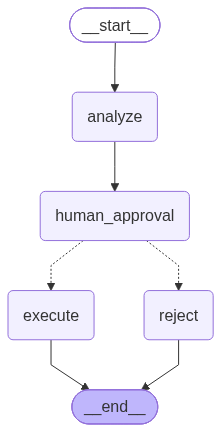

In [41]:
graph

In [38]:
config = {
    "configurable": {
        "thread_id": "refund_thread_1"
    }
}

In [39]:
result = graph.invoke(

    {
        "user_request":
        """
Customer CUST-101 received a damaged product.
Please refund ₹5000.
""",

        "action": "",
        "customer": "",
        "amount": 0,
        "reason": "",
        "approved": False,
        "final_message": ""
    },

    config=config
)

In [40]:
print(
    "\nGraph paused for human approval."
)


print(
    "\nInterrupt Information:"
)


print(
    result["__interrupt__"]
)



Graph paused for human approval.

Interrupt Information:
[Interrupt(value={'message': 'Please review the AI proposed action.', 'action': 'refund', 'customer': 'CUST-101', 'amount': 5000.0, 'reason': 'Customer received a damaged product and requested a refund.'}, id='5dc0736876097bde64b714418bc16b94')]


In [42]:
human_input = input(
    "\nApprove action? (yes/no): "
).strip().lower()


In [43]:
human_input

'yes'

In [44]:
approved = (
    human_input == "yes"
)

In [45]:
approved

True

In [46]:
final_result = graph.invoke(

    Command(
        resume=approved
    ),

    config=config
)

In [47]:
print(
    "\nFinal Result:"
)

print(
    final_result["final_message"]
)


Final Result:
Refund of ₹5000.0 processed for CUST-101.
